## Test - Ivet


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


1. Load the sample data


In [21]:
from pathlib import Path

file_2023 = Path("../data/raw/sample_23.csv")
data_2023 = pd.read_csv(file_2023)

display(data_2023.head())
print("full shape:", data_2023.shape)


,ID,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
0,22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,...,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
1,42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,...,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
2,56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,...,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
3,58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,...,14.1510,20.087,13.762,14.6370,21.0030,25.3060,5.2450,13.2220,13.909,16.507
4,64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,...,2.5045,2.774,2.018,2.1118,2.1118,2.1118,2.1118,2.1118,2.367,2.729


full shape: (17547, 366)


2. Build an ID / date / value table


In [22]:
dates = [c for c in data_2023.columns if c != "ID"]
dates.sort()

long_rows = []
for _, row in data_2023.iterrows():
    for d in dates:
        long_rows.append({"ID": row["ID"], "date": d, "value": row[d]})

data_2023_long = pd.DataFrame(long_rows)
data_2023_long["date"] = pd.to_datetime(data_2023_long["date"])

display(data_2023_long.head())
print("long table shape:", data_2023_long.shape)


,ID,date,value
0,22.0,2023-01-01,13.482
1,22.0,2023-01-02,9.473
2,22.0,2023-01-03,10.146
3,22.0,2023-01-04,10.978
4,22.0,2023-01-05,14.149


long table shape: (6404655, 3)


3. Remove series that are all zeros


In [ ]:
zero_flags = (
    data_2023_long
    .groupby("ID")["value"]
    .apply(lambda s: (s == 0).all())
)

zero_ids = zero_flags[zero_flags].index.tolist()
print("IDs with only zeros:", len(zero_ids))
if zero_ids:
    print("sample IDs:", zero_ids[:10])

data_2023_long_clean = (
    data_2023_long[~data_2023_long["ID"].isin(zero_ids)]
    .reset_index(drop=True)
)
print("clean long shape:", data_2023_long_clean.shape)


IDs with only zeros: 154
sample IDs: [7190.0, 7433.0, 8410.0, 14237.0, 14618.0, 16182.0, 17953.0, 18218.0, 19275.0, 19362.0]
clean long shape: (6348445, 3)


4. Build the time-series matrix

In [24]:
dates_sorted = sorted(data_2023_long_clean['date'].unique())
wide_profiles = (
    data_2023_long_clean
    .pivot_table(index='ID', columns='date', values='value')
    .reindex(columns=dates_sorted)
)
wide_profiles = wide_profiles.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)
wide_matrix = wide_profiles.to_numpy()
print(f"Wide profile matrix: {wide_profiles.shape[0]} IDs × {wide_profiles.shape[1]} days")
wide_profiles.head()


Wide profile matrix: 17393 IDs × 365 days


/var/folders/6d/lgywsk1x6d3b2gh8qcdf_rr80000gn/T/ipykernel_24045/4076656018.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wide_profiles = wide_profiles.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)


date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
ID,,,,,,,,,,,,,,,,,,,,,
22.0,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,14.919,...,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
42.0,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,36.268,...,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
56.0,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,8.156,...,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
58.0,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,6.134,...,14.1510,20.087,13.762,14.6370,21.0030,25.3060,5.2450,13.2220,13.909,16.507
64.0,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,3.755,...,2.5045,2.774,2.018,2.1118,2.1118,2.1118,2.1118,2.1118,2.367,2.729


5.Visual sanity check

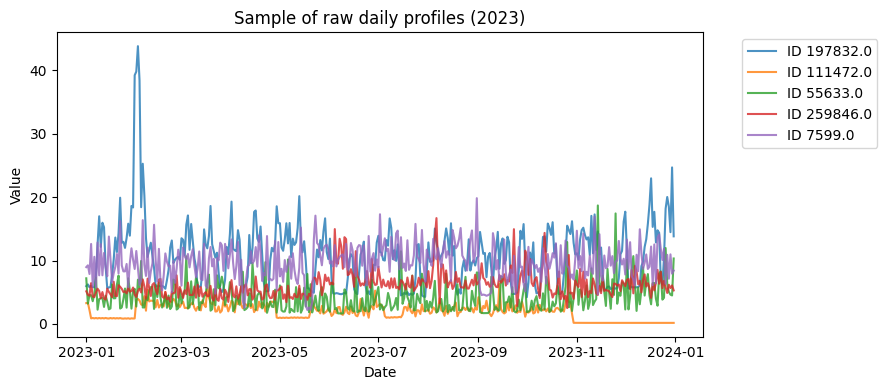

In [25]:
rng_preview = np.random.default_rng(2026)
preview_ids = rng_preview.choice(wide_profiles.index, size=min(5, len(wide_profiles)), replace=False)
plt.figure(figsize=(9, 4))
for series_id in preview_ids:
    plt.plot(dates_sorted, wide_profiles.loc[series_id], alpha=0.8, label=f'ID {series_id}')
plt.title('Sample of raw daily profiles (2023)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


6. Normalize

In [26]:
wide_mean = wide_matrix.mean(axis=1, keepdims=True)
wide_std = wide_matrix.std(axis=1, keepdims=True) + 1e-6
wide_norm = (wide_matrix - wide_mean) / wide_std

SAMPLE_FOR_CONSENSUS = 600
rng_sample = np.random.default_rng(2026)
sample_size = min(SAMPLE_FOR_CONSENSUS, len(wide_norm))
sample_positions = np.sort(rng_sample.choice(len(wide_norm), size=sample_size, replace=False))

sample_ids = wide_profiles.index.to_numpy()[sample_positions]
sample_matrix = wide_norm[sample_positions]
print(f"Using {sample_size} IDs (out of {len(wide_norm)}) for each consensus run")


Using 600 IDs (out of 17393) for each consensus run


7.clustering: DTW + k-medoids

In [27]:
def dtw_distance(ts_a, ts_b):
    n, m = len(ts_a), len(ts_b)
    dp = np.full((n + 1, m + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = (ts_a[i - 1] - ts_b[j - 1]) ** 2
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])
    return float(np.sqrt(dp[n, m]))

def build_distance_matrix(series_matrix):
    n = len(series_matrix)
    dist = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            d = dtw_distance(series_matrix[i], series_matrix[j])
            dist[i, j] = dist[j, i] = d
    return dist

def k_medoids_from_dist(dist_matrix, n_clusters, random_state, max_iter=60):
    rng_local = np.random.default_rng(random_state)
    n = dist_matrix.shape[0]
    medoids = rng_local.choice(n, size=n_clusters, replace=False)
    for _ in range(max_iter):
        distances = dist_matrix[:, medoids]
        labels = distances.argmin(axis=1)
        new_medoids = medoids.copy()
        for cluster in range(n_clusters):
            members = np.where(labels == cluster)[0]
            if len(members) == 0:
                candidates = np.setdiff1d(np.arange(n), new_medoids)
                if len(candidates) > 0:
                    new_medoids[cluster] = rng_local.choice(candidates)
                continue
            cluster_dist = dist_matrix[np.ix_(members, members)]
            costs = cluster_dist.sum(axis=1)
            new_medoids[cluster] = members[np.argmin(costs)]
        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids
    final_distances = dist_matrix[:, medoids]
    labels = final_distances.argmin(axis=1)
    return medoids, labels

sample_distance_matrix = build_distance_matrix(sample_matrix)
print('Computed DTW distance matrix with shape', sample_distance_matrix.shape)


Computed DTW distance matrix with shape (600, 600)


In [28]:
n_clusters = 4
initial_medoids, initial_labels = k_medoids_from_dist(sample_distance_matrix, n_clusters, random_state=2026)
initial_medoid_ids = sample_ids[initial_medoids]
print('Initial medoid IDs:', initial_medoid_ids.tolist())
print('Initial cluster sizes:', np.bincount(initial_labels))


Initial medoid IDs: [99800.0, 262132.0, 181144.0, 67390.0]
Initial cluster sizes: [ 96 206 199  99]


8. Consensus clustering step

- consensus stage using Jaccard similarity among resulting clusters

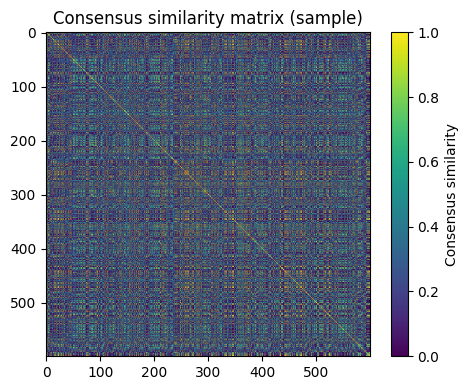

In [29]:
def build_consensus(sim_distance_matrix, n_clusters, n_runs=8, sample_ratio=0.85, random_state=2026):
    rng_local = np.random.default_rng(random_state)
    n = sim_distance_matrix.shape[0]
    agreement = np.zeros((n, n), dtype=float)
    cooccurrence = np.zeros((n, n), dtype=float)
    for run in range(n_runs):
        subset_size = max(n_clusters + 1, int(sample_ratio * n))
        subset_idx = np.sort(rng_local.choice(n, size=subset_size, replace=False))
        subset_dist = sim_distance_matrix[np.ix_(subset_idx, subset_idx)]
        medoids, labels = k_medoids_from_dist(subset_dist, n_clusters, rng_local.integers(1 << 32))
        for i_pos, i in enumerate(subset_idx):
            for j_pos, j in enumerate(subset_idx):
                cooccurrence[i, j] += 1
                if labels[i_pos] == labels[j_pos]:
                    agreement[i, j] += 1
    similarity = np.divide(agreement, cooccurrence, out=np.zeros_like(agreement), where=cooccurrence > 0)
    np.fill_diagonal(similarity, 1.0)
    return similarity, cooccurrence

consensus_similarity, consensus_counts = build_consensus(
    sample_distance_matrix,
    n_clusters=n_clusters,
    n_runs=8,
    sample_ratio=0.85,
    random_state=2026,
)
plt.figure(figsize=(5, 4))
plt.imshow(consensus_similarity, cmap='viridis')
plt.colorbar(label='Consensus similarity')
plt.title('Consensus similarity matrix (sample)')
plt.tight_layout()
plt.show()


9. Final clustering from the consensus matrix
- convert similarity to distance: 1 - consensus
- run k-medoids again on that matrix

In [ ]:
from sklearn.cluster import AgglomerativeClustering

def medoid_indices_from_labels(dist_matrix, labels):
    medoid_positions = []
    for cluster_id in sorted(np.unique(labels)):
        members = np.where(labels == cluster_id)[0]
        cluster_dist = dist_matrix[np.ix_(members, members)]
        costs = cluster_dist.sum(axis=1)
        medoid_positions.append(members[np.argmin(costs)])
    return medoid_positions

consensus_distance = 1.0 - consensus_similarity
np.fill_diagonal(consensus_distance, 0.0)
agg = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
sample_cluster_labels = agg.fit_predict(consensus_distance)
final_medoid_positions = medoid_indices_from_labels(sample_distance_matrix, sample_cluster_labels)
final_medoid_ids = sample_ids[final_medoid_positions]
print('Final consensus cluster sizes (sample):', np.bincount(sample_cluster_labels))
print('Final medoid IDs:', final_medoid_ids.tolist())

id_to_pos = {id_val: idx for idx, id_val in enumerate(wide_profiles.index.to_numpy())}
medoid_positions_full = [id_to_pos[mid] for mid in final_medoid_ids]
medoid_vectors = wide_norm[medoid_positions_full]

diff = wide_norm[:, None, :] - medoid_vectors[None, :, :]
all_distances = np.sqrt((diff ** 2).sum(axis=2))
full_cluster_labels = all_distances.argmin(axis=1)
cluster_assignments = pd.DataFrame({
    'ID': wide_profiles.index.to_numpy(),
    'cluster': full_cluster_labels,
})
print('Cluster sizes (all IDs):')
print(cluster_assignments['cluster'].value_counts().sort_index())


Final consensus cluster sizes (sample): [232 282  25  61]
Final medoid IDs: [13930.0, 262132.0, 172966.0, 28114.0]
Cluster sizes (all IDs):
cluster
0    9850
1    2226
2    1991
3    3326
Name: count, dtype: int64


10. Cluster summary table

In [31]:
summary_rows = []
for cluster_id in sorted(cluster_assignments['cluster'].unique()):
    member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
    subset = wide_profiles.loc[member_ids]
    summary_rows.append({
        'cluster': int(cluster_id),
        'n_ids': len(member_ids),
        'medoid_id': int(final_medoid_ids[cluster_id]),
        'mean_level': subset.mean(axis=1).mean(),
        'std_level': subset.std(axis=1).mean(),
        'avg_range': (subset.max(axis=1) - subset.min(axis=1)).mean(),
    })
cluster_summary = pd.DataFrame(summary_rows)
cluster_summary


,cluster,n_ids,medoid_id,mean_level,std_level,avg_range
0,0,9850,13930,10.375288,5.654588,29.226606
1,1,2226,262132,8.069364,3.091513,19.063268
2,2,1991,172966,8.526991,3.808203,21.735562
3,3,3326,28114,6.941155,2.710353,17.080022


11. Plot the average profile of each final cluster

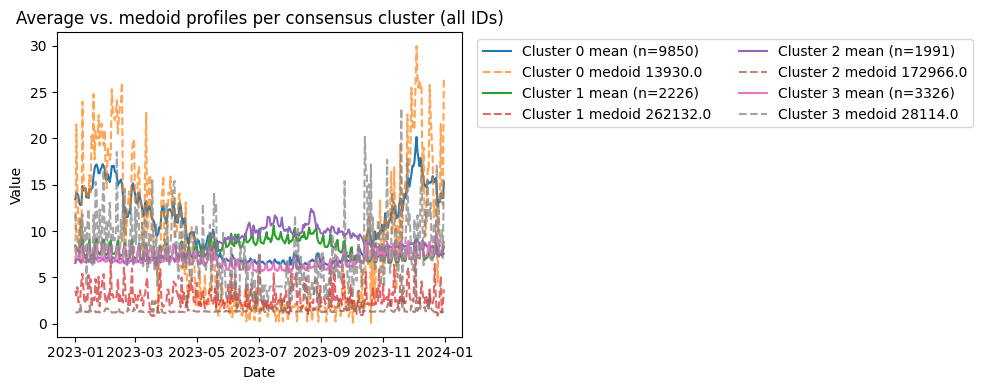

In [32]:
plt.figure(figsize=(10, 4))
for cluster_id in sorted(cluster_assignments['cluster'].unique()):
    member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
    mean_profile = wide_profiles.loc[member_ids].mean(axis=0)
    plt.plot(dates_sorted, mean_profile, label=f'Cluster {cluster_id} mean (n={len(member_ids)})')
    medoid_id = final_medoid_ids[cluster_id]
    plt.plot(dates_sorted, wide_profiles.loc[medoid_id], linestyle='--', alpha=0.7, label=f'Cluster {cluster_id} medoid {medoid_id}')
plt.title('Average vs. medoid profiles per consensus cluster (all IDs)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


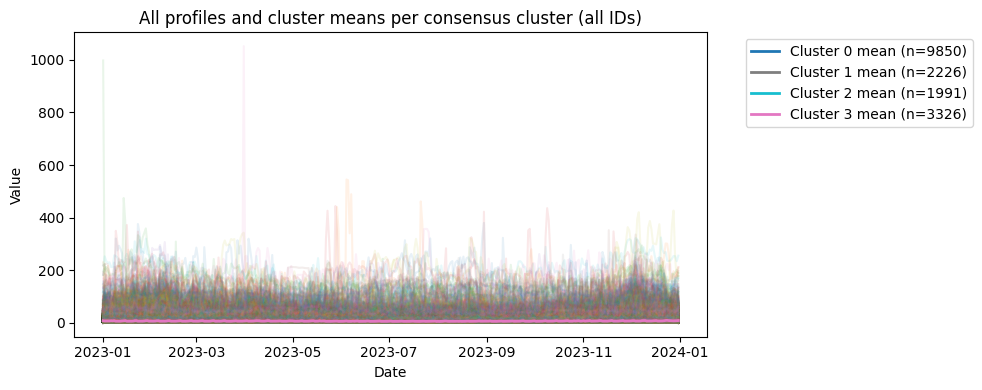

In [34]:
plt.figure(figsize=(10, 4))
for cluster_id in sorted(cluster_assignments['cluster'].unique()):
    member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
    for series_id in member_ids:
        plt.plot(dates_sorted, wide_profiles.loc[series_id], alpha=0.1)
    mean_profile = wide_profiles.loc[member_ids].mean(axis=0)
    plt.plot(dates_sorted, mean_profile, label=f'Cluster {cluster_id} mean (n={len(member_ids)})', linewidth=2)
plt.title('All profiles and cluster means per consensus cluster (all IDs)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

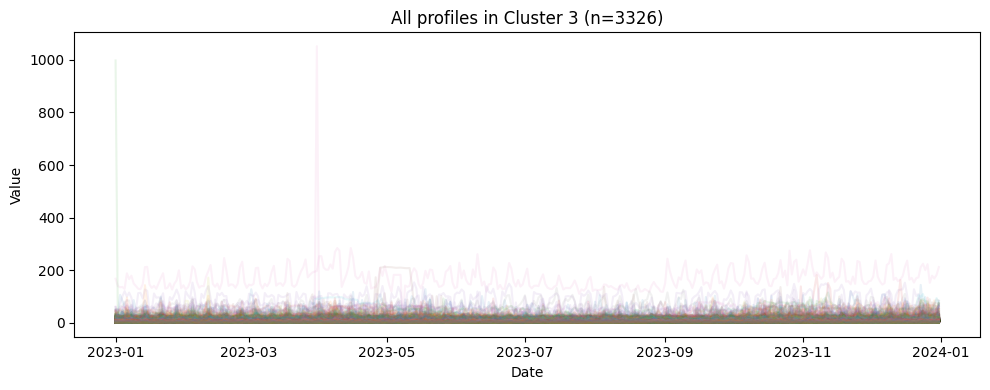

In [ ]:
plt.figure(figsize=(10, 4))
cluster_id = 3
member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
for series_id in member_ids:
    plt.plot(dates_sorted, wide_profiles.loc[series_id], alpha=0.1)
plt.title(f'All profiles in Cluster {cluster_id} (n={len(member_ids)})')
plt.xlabel('Date')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


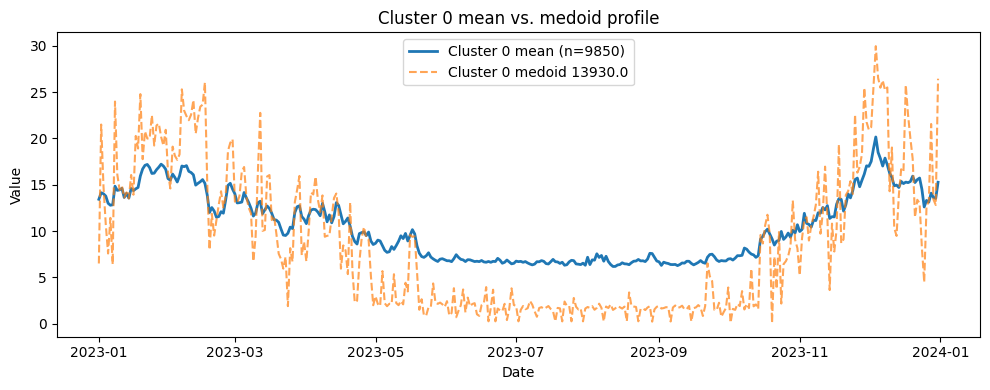

In [ ]:
plt.figure(figsize=(10, 4))
cluster_id = 0
member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
mean_profile = wide_profiles.loc[member_ids].mean(axis=0)
plt.plot(dates_sorted, mean_profile, label=f'Cluster {cluster_id} mean (n={len(member_ids)})', linewidth=2)
medoid_id = final_medoid_ids[cluster_id]
plt.plot(dates_sorted, wide_profiles.loc[medoid_id], linestyle='--', alpha=0.7, label=f'Cluster {cluster_id} medoid {medoid_id}')
plt.title(f'Cluster {cluster_id} mean vs. medoid profile')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

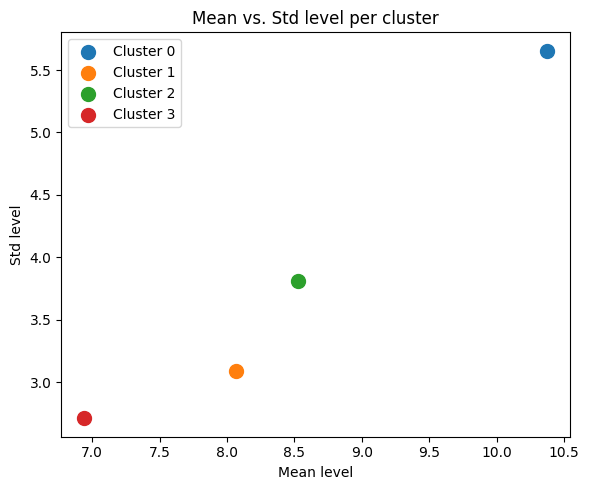

In [ ]:
plt.figure(figsize=(6, 5))
for cluster_id in sorted(cluster_summary['cluster'].unique()):  
    cluster_data = cluster_summary[cluster_summary['cluster'] == cluster_id]
    plt.scatter(cluster_data['mean_level'], cluster_data['std_level'], label=f'Cluster {cluster_id}', s=100)
plt.title('Mean vs. Std level per cluster')
plt.xlabel('Mean level')
plt.ylabel('Std level')
plt.legend()
plt.tight_layout()
plt.show()

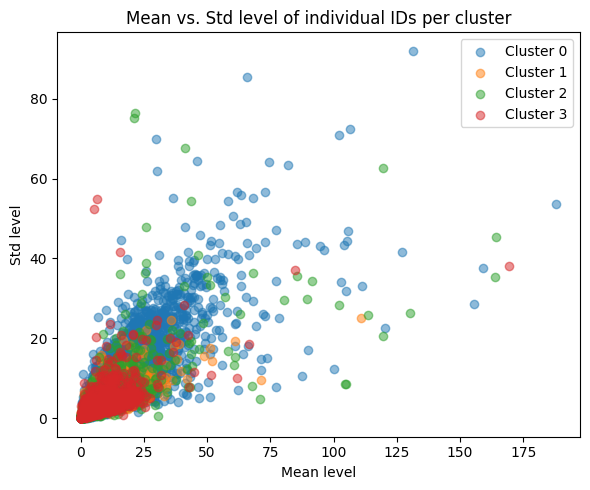

In [ ]:
plt.figure(figsize=(6, 5))
for cluster_id in sorted(cluster_assignments['cluster'].unique()):  
    member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
    cluster_data = wide_profiles.loc[member_ids]
    mean_levels = cluster_data.mean(axis=1)
    std_levels = cluster_data.std(axis=1)
    plt.scatter(mean_levels, std_levels, label=f'Cluster {cluster_id}', alpha=0.5)
plt.title('Mean vs. Std level of individual IDs per cluster')
plt.xlabel('Mean level')
plt.ylabel('Std level')
plt.legend()
plt.tight_layout()
plt.show()

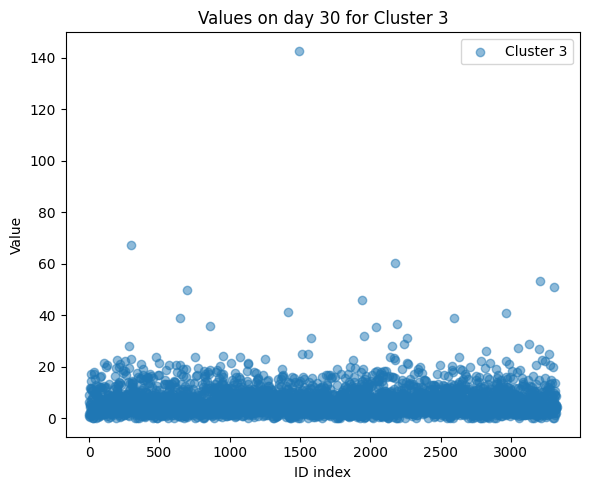

In [ ]:
plt.figure(figsize=(6, 5))
cluster_id = 3
member_ids = cluster_assignments.loc[cluster_assignments['cluster'] == cluster_id, 'ID']
cluster_data = wide_profiles.loc[member_ids]
day_idx = 30
day_values = cluster_data.iloc[:, day_idx]
plt.scatter(range(len(day_values)), day_values, label=f'Cluster {cluster_id}', alpha=0.5)
plt.title(f'Values on day {day_idx} for Cluster {cluster_id}')
plt.xlabel('ID index')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()
